In [4]:
# 1. Importar librerías
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 2. Cargar el dataset
# Asegúrate de haber subido el archivo 'dataset_elpino.csv'
df = pd.read_csv('dataset/dataset_elpino.csv', sep=';', engine='python')

# 3. Codificar la columna de Sexo (Hombre -> 0, Mujer -> 1)
df['Sexo codificado'] = df['Sexo (Desc)'].map({
    'Hombre': 0,
    'Mujer': 1
})

# 4. Extraer solo el código del Diagnóstico Principal y Procedimiento Principal
df['Diag Principal Codigo'] = df['Diag 01 Principal (cod+des)'].apply(lambda x: str(x).split(' - ')[0])
df['Proced Principal Codigo'] = df['Proced 01 Principal (cod+des)'].apply(lambda x: str(x).split(' - ')[0])

# 5. Filtrar GRDs con al menos 3 pacientes
grd_counts = df['GRD'].value_counts()
grds_validos = grd_counts[grd_counts >= 3].index
df_filtrado = df[df['GRD'].isin(grds_validos)]

# 6. Definir Features (X) y Target (y) con el dataset filtrado
X = df_filtrado[['Edad en años', 'Sexo codificado', 'Diag Principal Codigo', 'Proced Principal Codigo']]
y = df_filtrado['GRD']

# 7. Codificar Diagnóstico Principal y Procedimiento Principal como números
le_diag = LabelEncoder()
le_proc = LabelEncoder()
X['Diag Principal Codigo'] = le_diag.fit_transform(X['Diag Principal Codigo'])
X['Proced Principal Codigo'] = le_proc.fit_transform(X['Proced Principal Codigo'])

# 8. Dividir en conjunto de entrenamiento y prueba (80% - 20%) usando stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 9. Mostrar tamaños de los conjuntos
print("Tamaño de conjunto de entrenamiento:", X_train.shape)
print("Tamaño de conjunto de prueba:", X_test.shape)

Tamaño de conjunto de entrenamiento: (11500, 4)
Tamaño de conjunto de prueba: (2875, 4)


/var/folders/qv/72zlgj153b72qr4t7jm9d4gw0000gn/T/ipykernel_25005/1712179374.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Diag Principal Codigo'] = le_diag.fit_transform(X['Diag Principal Codigo'])
/var/folders/qv/72zlgj153b72qr4t7jm9d4gw0000gn/T/ipykernel_25005/1712179374.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Proced Principal Codigo'] = le_proc.fit_transform(X['Proced Principal Codigo'])


/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-d

Accuracy de la Regresión Logística: 0.1757

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00        17
           7       0.00      0.00      0.00        13
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         9
          13       0.00      0.00      0.00         5
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         4
          16  

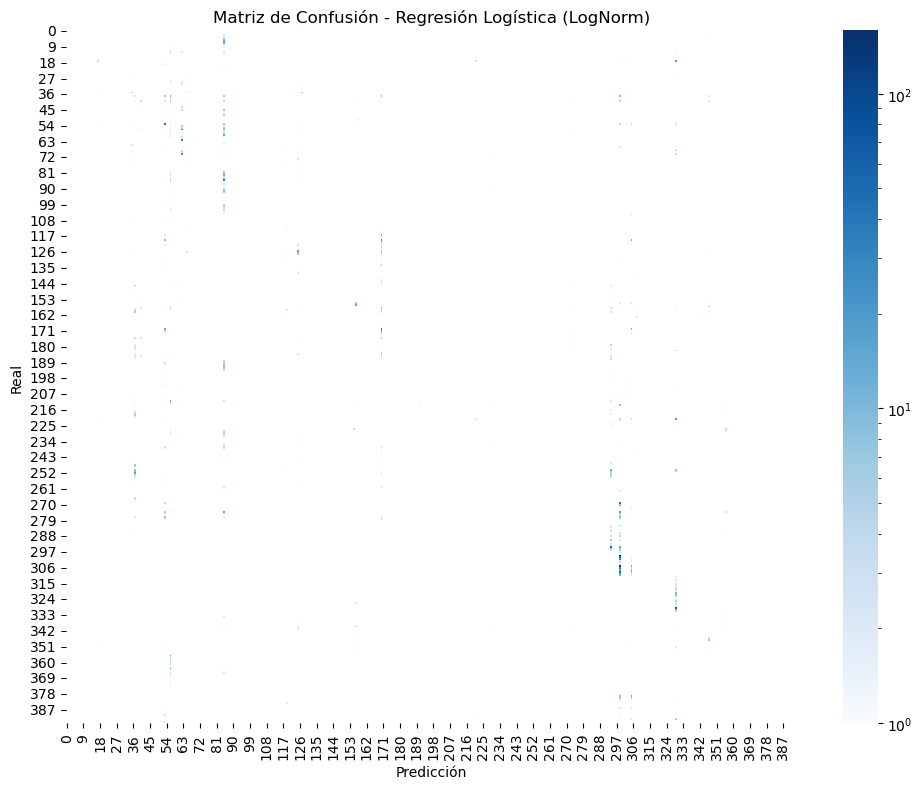

In [27]:
# 1. Importar librerías necesarias
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Inicializar el modelo de Regresión Logística
modelo_log = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42
)

# 3. Entrenar el modelo
modelo_log.fit(X_train, y_train)

# 4. Hacer predicciones
y_pred = modelo_log.predict(X_test)

# 5. Codificar las predicciones con el mismo codificador usado para y_test_encoded
y_pred_encoded = le_target.transform(y_pred)

# 6. Evaluar el modelo
acc = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"Accuracy de la Regresión Logística: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_encoded))

# 7. Matriz de Confusión con escala logarítmica
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_encoded), cmap='Blues', norm=LogNorm())
plt.title('Matriz de Confusión - Regresión Logística (LogNorm)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

Accuracy del Árbol de Decisión: 0.4595

Classification Report:
                                                                                                           precision    recall  f1-score   support

                           014112 - MH ENFERMEDADES DEGENERATIVAS Y NEOPLÁSICAS DEL SISTEMA NERVIOSO W/CC       0.00      0.00      0.00         1
                          014113 - MH ENFERMEDADES DEGENERATIVAS Y NEOPLÁSICAS DEL SISTEMA NERVIOSO W/MCC       0.00      0.00      0.00         1
                                                        014131 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA       0.00      0.00      0.00         2
                                                   014132 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA W/CC       0.20      1.00      0.33         2
                                                  014133 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA W/MCC       0.00      0.00      0.00         3
                                                      

/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

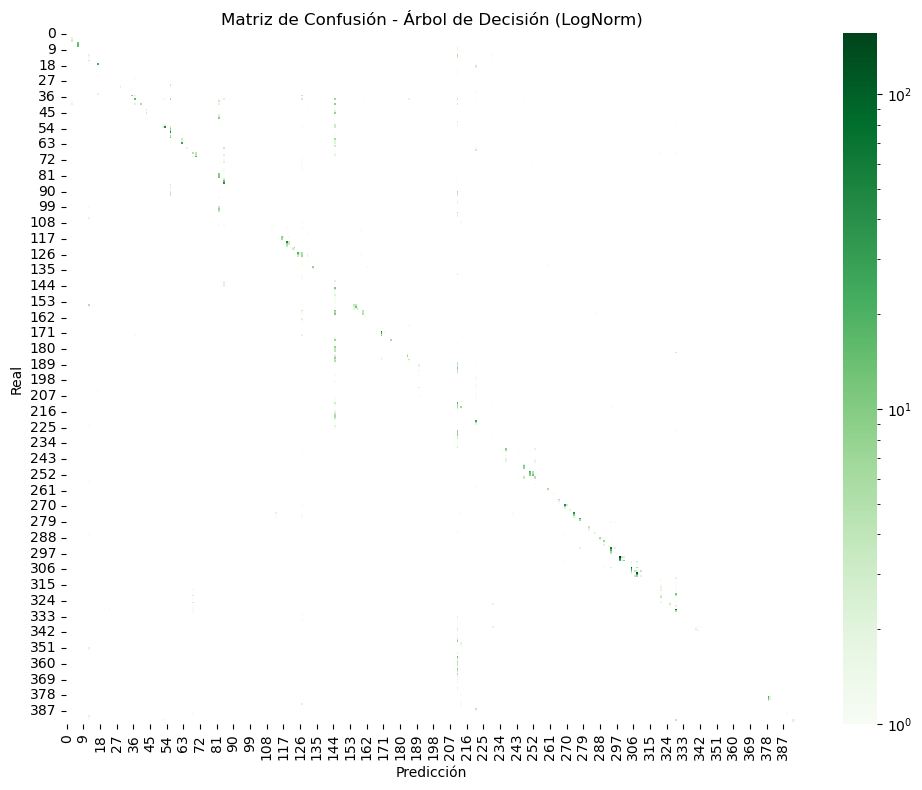

In [28]:
# 1. Importar librerías necesarias
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Inicializar y entrenar el modelo
modelo_arbol = DecisionTreeClassifier(
    max_depth=10,        # Profundidad del árbol (ajustable)
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

# 3. Hacer predicciones
y_pred_arbol = modelo_arbol.predict(X_test)
y_pred_arbol_encoded = le_target.transform(y_pred_arbol)

# 4. Evaluar el desempeño
acc_arbol = accuracy_score(y_test, y_pred_arbol)
precision_macro_arbol = precision_score(y_test, y_pred_arbol, average='macro', zero_division=0)
recall_macro_arbol = recall_score(y_test, y_pred_arbol, average='macro', zero_division=0)
f1_macro_arbol = f1_score(y_test, y_pred_arbol, average='macro', zero_division=0)

# 5. Mostrar resultados
print(f"Accuracy del Árbol de Decisión: {acc_arbol:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_arbol))

# # 6. Matriz de confusión
# plt.figure(figsize=(10, 8))
# sns.heatmap(confusion_matrix(y_test, y_pred_arbol), cmap='Greens', xticklabels=False, yticklabels=False)
# plt.title('Matriz de Confusión - Árbol de Decisión')
# plt.xlabel('Predicción')
# plt.ylabel('Real')
# plt.show()

# Matriz de confusión Árbol de Decisión con escala logarítmica
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_arbol_encoded), cmap='Greens', norm=LogNorm())
plt.title('Matriz de Confusión - Árbol de Decisión (LogNorm)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

Accuracy del Random Forest: 0.5416

Classification Report:
                                                                                                           precision    recall  f1-score   support

                           014112 - MH ENFERMEDADES DEGENERATIVAS Y NEOPLÁSICAS DEL SISTEMA NERVIOSO W/CC       0.00      0.00      0.00         1
                          014113 - MH ENFERMEDADES DEGENERATIVAS Y NEOPLÁSICAS DEL SISTEMA NERVIOSO W/MCC       0.00      0.00      0.00         1
                                                        014131 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA       0.00      0.00      0.00         2
                                                   014132 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA W/CC       0.00      0.00      0.00         2
                                                  014133 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA W/MCC       0.00      0.00      0.00         3
                                                        01

/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

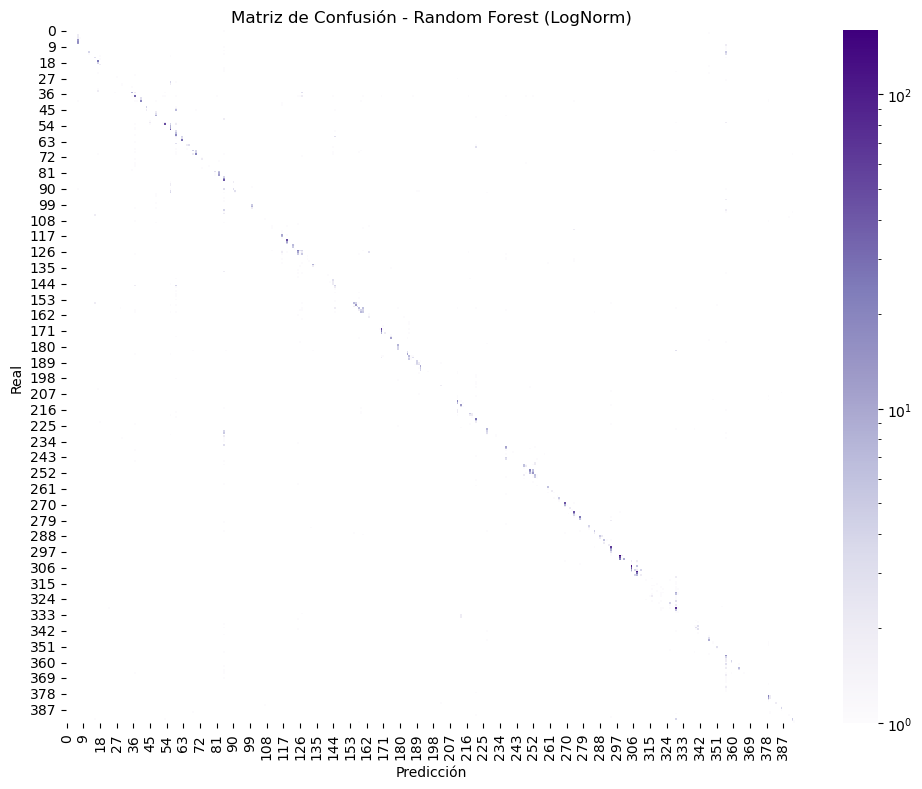

In [29]:
# 1. Importar librerías necesarias
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Inicializar y entrenar el modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,   # Número de árboles en el bosque
    max_depth=10,       # Profundidad máxima de cada árbol (igual que el árbol anterior para comparar justo)
    random_state=42,
    n_jobs=-1           # Utilizar todos los núcleos disponibles para acelerar el entrenamiento
)

modelo_rf.fit(X_train, y_train)

# 3. Hacer predicciones
y_pred_rf = modelo_rf.predict(X_test)
y_pred_rf_encoded = le_target.transform(y_pred_rf)


# 4. Evaluar el desempeño
acc_rf = accuracy_score(y_test, y_pred_rf)
precision_macro_rf = precision_score(y_test, y_pred_rf, average='macro', zero_division=0)
recall_macro_rf = recall_score(y_test, y_pred_rf, average='macro', zero_division=0)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

# 5. Mostrar resultados
print(f"Accuracy del Random Forest: {acc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# # 6. Matriz de confusión
# plt.figure(figsize=(10, 8))
# sns.heatmap(confusion_matrix(y_test, y_pred_rf), cmap='Purples', xticklabels=False, yticklabels=False)
# plt.title('Matriz de Confusión - Random Forest')
# plt.xlabel('Predicción')
# plt.ylabel('Real')
# plt.show()

# Matriz de confusión Random Forest con escala logarítmica
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_rf_encoded), cmap='Purples', norm=LogNorm())
plt.title('Matriz de Confusión - Random Forest (LogNorm)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

Accuracy del XGBoost: 0.5207

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.50      1.00      0.67         2
           4       0.25      0.33      0.29         3
           5       0.45      0.38      0.42        13
           6       0.47      0.53      0.50        17
           7       0.46      0.46      0.46        13
           8       0.50      0.50      0.50         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.57      0.44      0.50         9
          13       0.17      0.20      0.18         5
          14       0.50      0.50      0.50         2
          15       0.50      0.75      0.60         4
          16       0.00     

/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

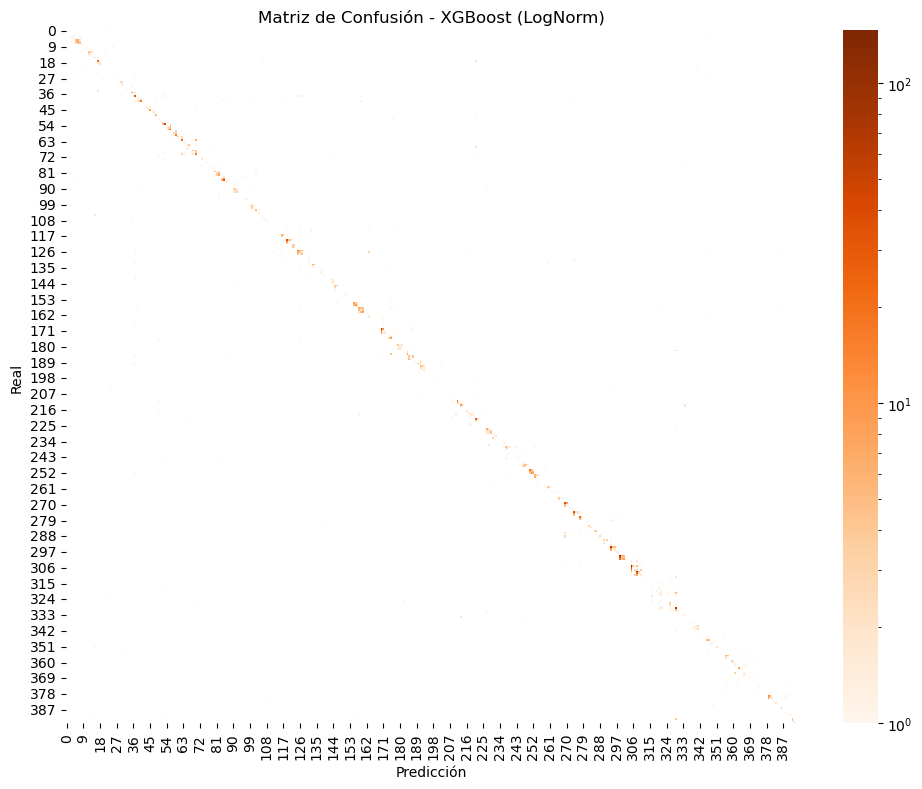

In [20]:
# 1. Importar librerías necesarias
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Codificar las etiquetas GRD para XGBoost
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)

# 3. Inicializar y entrenar el modelo XGBoost
modelo_xgb = XGBClassifier(
    n_estimators=100,      # 100 árboles
    max_depth=10,          # Profundidad máxima 10
    learning_rate=0.1,     # Velocidad de aprendizaje
    objective='multi:softmax', # Porque es multiclase
    num_class=len(le_target.classes_), # Número de clases distintas
    random_state=42,
    n_jobs=-1              # Usar todos los núcleos disponibles
)

modelo_xgb.fit(X_train, y_train_encoded)

# 4. Hacer predicciones
y_pred_xgb = modelo_xgb.predict(X_test)

# 5. Evaluar el desempeño
acc_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
precision_macro_xgb = precision_score(y_test_encoded, y_pred_xgb, average='macro', zero_division=0)
recall_macro_xgb = recall_score(y_test_encoded, y_pred_xgb, average='macro', zero_division=0)
f1_macro_xgb = f1_score(y_test_encoded, y_pred_xgb, average='macro', zero_division=0)

# 6. Mostrar resultados
print(f"Accuracy del XGBoost: {acc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_xgb))

# 7. Matriz de confusión
# Matriz de confusión con escala logarítmica
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_xgb), cmap='Oranges', norm=LogNorm())
plt.title('Matriz de Confusión - XGBoost (LogNorm)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calcular métricas para Regresión Logística
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

In [16]:
import pandas as pd

# Crear una lista de diccionarios con los resultados reales
resultados_lista = [
    {
        'Modelo': 'Regresión Logística',
        'Accuracy': acc,  # Accuracy real de Regresión Logística
        'Precision (Macro)': precision_macro,
        'Recall (Macro)': recall_macro,
        'F1-Score (Macro)': f1_macro
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Accuracy': acc_arbol,
        'Precision (Macro)': precision_macro_arbol,
        'Recall (Macro)': recall_macro_arbol,
        'F1-Score (Macro)': f1_macro_arbol
    },
    {
        'Modelo': 'Random Forest',
        'Accuracy': acc_rf,
        'Precision (Macro)': precision_macro_rf,
        'Recall (Macro)': recall_macro_rf,
        'F1-Score (Macro)': f1_macro_rf
    },
    {
        'Modelo': 'XGBoost',
        'Accuracy': acc_xgb,
        'Precision (Macro)': precision_macro_xgb,
        'Recall (Macro)': recall_macro_xgb,
        'F1-Score (Macro)': f1_macro_xgb
    }
]

# Crear el DataFrame automáticamente
resultados_modelos = pd.DataFrame(resultados_lista)

# Mostrar la tabla
print("\nTabla comparativa de todos los modelos (extraída automáticamente):")
print(resultados_modelos)


Tabla comparativa de todos los modelos (extraída automáticamente):
                Modelo  Accuracy  Precision (Macro)  Recall (Macro)  \
0  Regresión Logística  0.175652           0.009537        0.023411   
1    Árbol de Decisión  0.459478           0.113588        0.131845   
2        Random Forest  0.541565           0.166944        0.195266   
3              XGBoost  0.520696           0.257387        0.257686   

   F1-Score (Macro)  
0          0.012120  
1          0.110474  
2          0.166366  
3          0.245629  


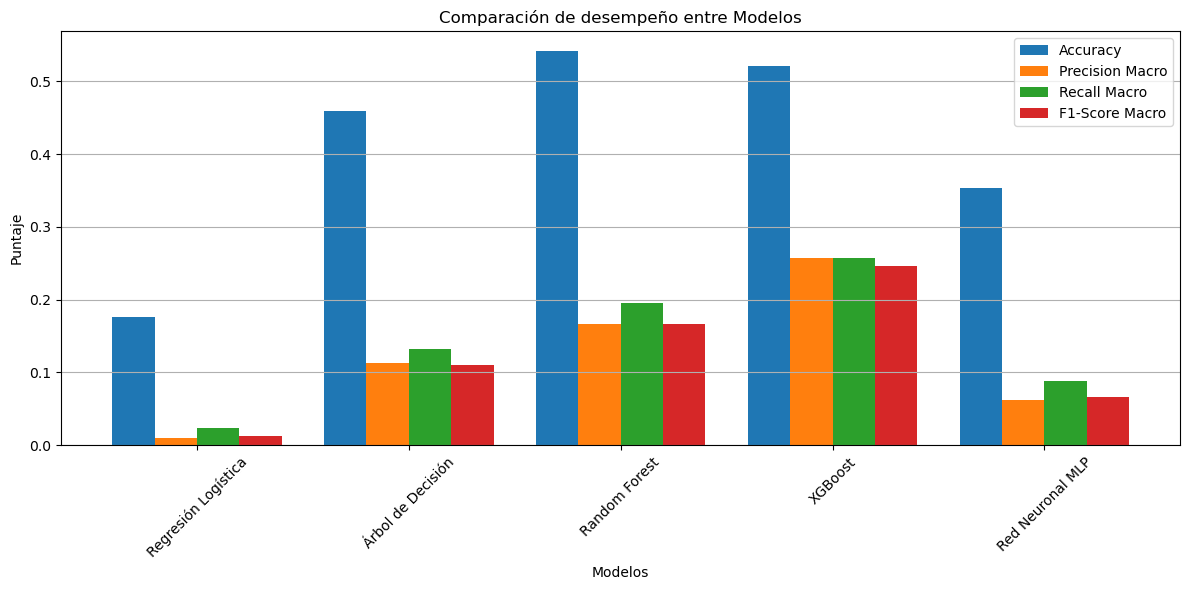

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Posiciones para cada modelo
modelos = resultados_modelos['Modelo']
x = np.arange(len(modelos))

# 2. Ancho de cada grupo de barras
width = 0.2

# 3. Crear la figura
fig, ax = plt.subplots(figsize=(12, 6))

# 4. Crear barras para cada métrica
bars1 = ax.bar(x - 1.5*width, resultados_modelos['Accuracy'], width, label='Accuracy')
bars2 = ax.bar(x - 0.5*width, resultados_modelos['Precision (Macro)'], width, label='Precision Macro')
bars3 = ax.bar(x + 0.5*width, resultados_modelos['Recall (Macro)'], width, label='Recall Macro')
bars4 = ax.bar(x + 1.5*width, resultados_modelos['F1-Score (Macro)'], width, label='F1-Score Macro')

# 5. Configurar etiquetas y título
ax.set_xlabel('Modelos')
ax.set_ylabel('Puntaje')
ax.set_title('Comparación de desempeño entre Modelos')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=45)
ax.legend()

# 6. Agregar líneas de grilla
ax.yaxis.grid(True)

# 7. Ajustar espacio y mostrar
plt.tight_layout()
plt.show()

In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# 1. Inicializar el modelo MLPClassifier
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),  # Una capa oculta con 100 neuronas
    max_iter=100,               # Número de épocas
    random_state=42,
    verbose=False
)

# 2. Entrenar el modelo
modelo_mlp.fit(X_train, y_train_encoded)

# 3. Predecir sobre el conjunto de prueba
y_pred_mlp_encoded = modelo_mlp.predict(X_test)

# 4. Evaluar el desempeño del modelo
acc_mlp = accuracy_score(y_test_encoded, y_pred_mlp_encoded)
precision_macro_mlp = precision_score(y_test_encoded, y_pred_mlp_encoded, average='macro', zero_division=0)
recall_macro_mlp = recall_score(y_test_encoded, y_pred_mlp_encoded, average='macro', zero_division=0)
f1_macro_mlp = f1_score(y_test_encoded, y_pred_mlp_encoded, average='macro', zero_division=0)

# 5. Mostrar métricas
print(f"Accuracy del MLP: {acc_mlp:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_mlp_encoded))


Accuracy del MLP: 0.3530

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00        17
           7       0.21      0.77      0.33        13
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         9
          13       0.12      0.20      0.15         5
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         4
          16       0.00      0.0

/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/juanpablovonmarttens/anaconda3/lib/python3.11/sit

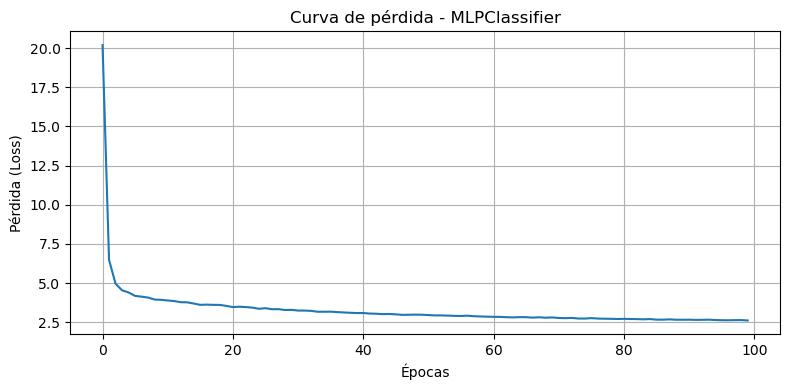

In [31]:
# Verifica que el modelo tenga el atributo loss_curve_
if hasattr(modelo_mlp, 'loss_curve_'):
    plt.figure(figsize=(8, 4))
    plt.plot(modelo_mlp.loss_curve_)
    plt.title('Curva de pérdida - MLPClassifier')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida (Loss)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


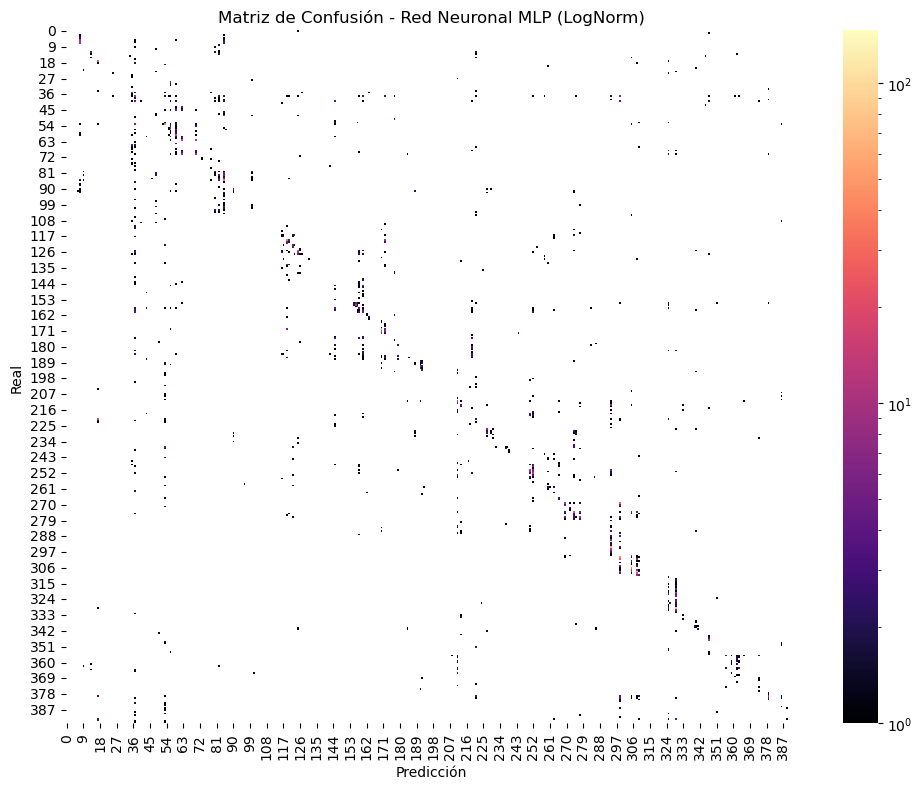

In [32]:
# Matriz de confusión codificada
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_mlp_encoded), cmap='magma', norm=LogNorm())
plt.title('Matriz de Confusión - Red Neuronal MLP (LogNorm)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


In [33]:
# Agregar a resultados_modelos
nuevo_resultado_mlp = pd.DataFrame({
    'Modelo': ['Red Neuronal MLP'],
    'Accuracy': [acc_mlp],
    'Precision (Macro)': [precision_macro_mlp],
    'Recall (Macro)': [recall_macro_mlp],
    'F1-Score (Macro)': [f1_macro_mlp]
})

resultados_modelos = pd.concat([resultados_modelos, nuevo_resultado_mlp], ignore_index=True)

# Mostrar tabla actualizada
print("\nTabla comparativa actualizada:")
print(resultados_modelos)



Tabla comparativa actualizada:
                Modelo  Accuracy  Precision (Macro)  Recall (Macro)  \
0  Regresión Logística  0.175652           0.009537        0.023411   
1    Árbol de Decisión  0.459478           0.113588        0.131845   
2        Random Forest  0.541565           0.166944        0.195266   
3              XGBoost  0.520696           0.257387        0.257686   
4     Red Neuronal MLP  0.353043           0.062428        0.087690   

   F1-Score (Macro)  
0          0.012120  
1          0.110474  
2          0.166366  
3          0.245629  
4          0.066372  
